# Construcción de modelos de Machine Learning
## Detección de cianobacteria en los lagos Atitlán y Amatitlán

Este notebook construye tres modelos de clasificación binaria para predecir la presencia de cianobacteria (alta = 1, baja/ausente = 0) a partir del dataset preparado en los notebooks anteriores.

**Modelos entrenados:**
1. Regresión Logística (baseline interpretable)
2. Random Forest
3. XGBoost (Gradient Boosting)

**Dataset:** 13,514,711 observaciones × 12 variables predictoras.

**División de datos:** 70% entrenamiento (9,460,297 obs) / 30% prueba (4,054,414 obs), estratificada.

**Desbalance de clases:** 97.77% clase 0 / 2.23% clase 1 (301,089 píxeles positivos en total).

**Manejo del desbalance:** `class_weight='balanced'` en Regresión Logística y Random Forest; `scale_pos_weight=43.89` en XGBoost.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, precision_score, recall_score, accuracy_score
)

import xgboost as xgb

np.random.seed(42)
Path('./modelos').mkdir(exist_ok=True)

## 1. Carga de datos

In [2]:
X = pd.read_parquet('./data/X_predictoras.parquet')
y = pd.read_parquet('./data/y_respuesta.parquet').squeeze()

# También cargar el dataset completo para tener metadatos (lago, fecha)
df_meta = pd.read_parquet('./data/dataset_ml_con_respuesta.parquet')[['lago', 'fecha', 'lon', 'lat']]

print(f'Predictores: {X.shape[0]:,} observaciones x {X.shape[1]} variables')
print(f'Variable respuesta: {y.shape[0]:,} observaciones')
print(f'Columnas en X: {list(X.columns)}')
print(f'\nDistribución de clases:')
print(y.value_counts())
print(f'% clase 1: {100 * y.mean():.2f}%')

Predictores: 13,514,711 observaciones x 12 variables
Variable respuesta: 13,514,711 observaciones
Columnas en X: ['B03', 'B08', 'NDVI', 'NDWI', 'lon', 'lat', 'dist_centro_lago', 'mes_sin', 'mes_cos', 'epoca_lluviosa', 'brillo_B03_B08', 'lago_atitlan']

Distribución de clases:
cianobacteria_alta
0    13213622
1      301089
Name: count, dtype: int64
% clase 1: 2.23%


## 2. División entrenamiento / prueba (70/30, estratificada)

### 4.2 División convencional

Se usa `stratify=y` para asegurar que la proporción de clase 1 en entrenamiento y prueba sea igual a la del dataset completo. Con un desbalance severo de 2.23%, una partición sin estratificación podría producir folds con proporciones muy distintas de positivos.

**Resultado:**
- Entrenamiento: 9,460,297 observaciones — clase 1: 210,762 (2.23%)
- Prueba: 4,054,414 observaciones — clase 1: 90,327 (2.23%)

In [3]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df_meta.index,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Guardar índices de prueba para reutilizar en notebooks posteriores
pd.Series(idx_test).to_frame(name='idx').to_parquet('./data/idx_test.parquet')

print('Conjunto de entrenamiento:')
print(f'  Total: {len(X_train):,} observaciones')
print(f'  Clase 1: {y_train.sum():,} ({100*y_train.mean():.2f}%)')
print()
print('Conjunto de prueba:')
print(f'  Total: {len(X_test):,} observaciones')
print(f'  Clase 1: {y_test.sum():,} ({100*y_test.mean():.2f}%)')

Conjunto de entrenamiento:
  Total: 9,460,297 observaciones
  Clase 1: 210,762 (2.23%)

Conjunto de prueba:
  Total: 4,054,414 observaciones
  Clase 1: 90,327 (2.23%)


## 3. Definición de la escala de pesos para el desbalance

El desbalance (97.77% clase 0 / 2.23% clase 1) se aborda de forma diferenciada según el modelo:

- **Regresión Logística y Random Forest**: `class_weight='balanced'`, que asigna a cada muestra de la clase minoritaria un peso proporcional a la inversa de su frecuencia relativa.
- **XGBoost**: parámetro `scale_pos_weight = n_neg / n_pos = 9,249,535 / 210,762 = 43.89`, equivalente a decirle al modelo que cada positivo vale ~44 negativos.

In [4]:
n_neg_train = (y_train == 0).sum()
n_pos_train = (y_train == 1).sum()
scale_pos_weight = n_neg_train / n_pos_train

print(f'n negativos en train: {n_neg_train:,}')
print(f'n positivos en train: {n_pos_train:,}')
print(f'scale_pos_weight (para XGBoost): {scale_pos_weight:.2f}')

n negativos en train: 9,249,535
n positivos en train: 210,762
scale_pos_weight (para XGBoost): 43.89


## 4. Modelo 1: Regresión Logística

### 4.1 Entrenamiento inicial

La regresión logística sirve como **baseline interpretable**. Al ser un modelo lineal, permite identificar qué predictores están más asociados con la clase positiva a través de los coeficientes.

Se usa una pipeline con `StandardScaler` porque la regresión logística con regularización L2 es sensible a la escala de las variables (los coeficientes del regularizador penalizan por igual a todas las variables sin importar su magnitud).

In [5]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        solver='lbfgs',
        C=1.0  # regularización L2 por defecto; se ajustará en la sección 4.3
    ))
])

pipeline_lr.fit(X_train, y_train)
print('Regresión Logística entrenada.')

Regresión Logística entrenada.


### 4.3 Ajuste de hiperparámetros: Regresión Logística

El principal hiperparámetro a ajustar es `C` (inverso de la fuerza de regularización):
- **C pequeño** → mayor regularización → modelo más simple, menos varianza pero más sesgo.
- **C grande** → menor regularización → modelo más flexible, riesgo de sobreajuste.

Por limitaciones de recursos computacionales, el search se realiza sobre una **submuestra estratificada de 50,000 observaciones** con 3-fold CV y 10 iteraciones. El modelo con los mejores hiperparámetros encontrados se reentrenó sobre el dataset completo (9.46M observaciones).

**Resultado:** `C=0.00826`, `solver='liblinear'` — AUC-ROC en CV: **0.9418**

In [6]:
from scipy.stats import loguniform

# Submuestra estratificada para todos los searches (evita saturar RAM/CPU)
# El fit final de cada modelo se hace sobre X_train completo
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train,
    train_size=50000,
    stratify=y_train,
    random_state=42
)
print(f'Submuestra para search: {len(X_train_small):,} obs '
      f'(clase 1: {y_train_small.sum():,}, {100*y_train_small.mean():.2f}%)')

param_dist_lr = {
    'clf__C': loguniform(1e-3, 1e2),
    'clf__solver': ['lbfgs', 'liblinear']
}

cv_estratificado = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search_lr = RandomizedSearchCV(
    pipeline_lr,
    param_distributions=param_dist_lr,
    n_iter=10,
    scoring='roc_auc',
    cv=cv_estratificado,
    random_state=42,
    n_jobs=1,
    verbose=1
)

search_lr.fit(X_train_small, y_train_small)

print(f'Mejores hiperparámetros LR: {search_lr.best_params_}')
print(f'AUC-ROC en validación cruzada: {search_lr.best_score_:.4f}')

# Reentrenar con los mejores hiperparámetros sobre el dataset completo
mejor_lr = search_lr.best_estimator_
mejor_lr.fit(X_train, y_train)
print('Regresión Logística reentrenada sobre X_train completo.')

Submuestra para search: 50,000 obs (clase 1: 1,114, 2.23%)
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Mejores hiperparámetros LR: {'clf__C': np.float64(0.008263688714158009), 'clf__solver': 'liblinear'}
AUC-ROC en validación cruzada: 0.9418
Regresión Logística reentrenada sobre X_train completo.


### Coeficientes del mejor modelo de Regresión Logística

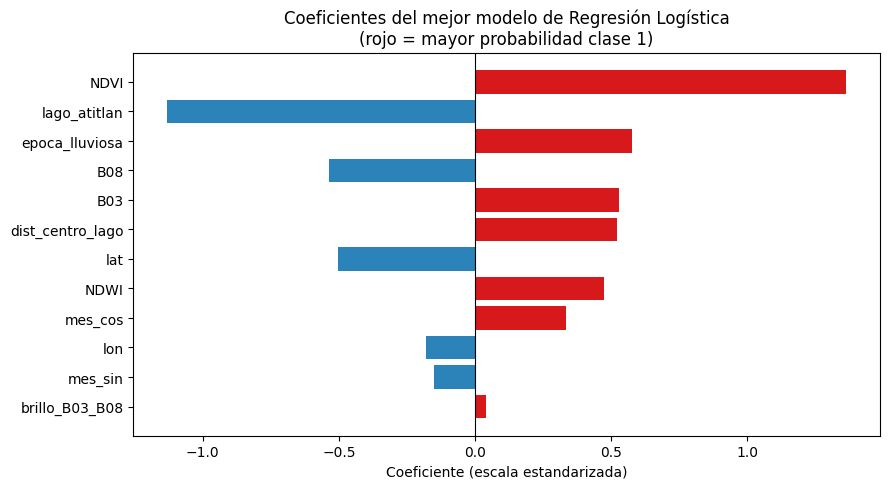

In [7]:
coeficientes = pd.Series(
    mejor_lr.named_steps['clf'].coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d7191c' if c > 0 else '#2b83ba' for c in coeficientes]
ax.barh(coeficientes.index[::-1], coeficientes.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (escala estandarizada)')
ax.set_title('Coeficientes del mejor modelo de Regresión Logística\n(rojo = mayor probabilidad clase 1)')
plt.tight_layout()
plt.show()

## 5. Modelo 2: Random Forest

### 4.1 Entrenamiento inicial

Random Forest es un ensamble de árboles de decisión que reduce la varianza mediante bagging y selección aleatoria de variables. Es naturalmente robusto a escala de variables (no requiere estandarización), captura relaciones no lineales e interacciones entre variables, y produce estimaciones de importancia de variables directamente.

In [8]:
# Entrenamiento inicial sobre submuestra para verificar que el modelo funciona
rf_inicial = RandomForestClassifier(
    n_estimators=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=1
)

rf_inicial.fit(X_train_small, y_train_small)
print('Random Forest inicial entrenado (sobre submuestra).')

Random Forest inicial entrenado (sobre submuestra).


### 4.3 Ajuste de hiperparámetros: Random Forest

Hiperparámetros explorados:
- `n_estimators`: número de árboles. Más árboles → menor varianza, pero mayor costo computacional.
- `max_depth`: profundidad máxima. Limitar evita sobreajuste.
- `min_samples_leaf`: mínimo de muestras en una hoja. Valores más altos generalizan mejor.
- `max_features`: número de características evaluadas en cada split. Controla la correlación entre árboles.

Search realizado sobre submuestra de 50,000 obs, 3-fold CV, 10 iteraciones. Reentrenamiento final sobre dataset completo.

**Mejores hiperparámetros:** `max_depth=20`, `max_features='sqrt'`, `min_samples_leaf=2`, `n_estimators=137` — AUC-ROC en CV: **0.9879**

In [9]:
from scipy.stats import randint

param_dist_rf = {
    'n_estimators': randint(50, 200),
    'max_depth': [10, 20, 30],
    'min_samples_leaf': randint(1, 20),
    'max_features': ['sqrt', 'log2']
}

search_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1),
    param_distributions=param_dist_rf,
    n_iter=10,
    scoring='roc_auc',
    cv=cv_estratificado,
    random_state=42,
    n_jobs=1,
    verbose=1
)

search_rf.fit(X_train_small, y_train_small)

print(f'Mejores hiperparámetros RF: {search_rf.best_params_}')
print(f'AUC-ROC en validación cruzada: {search_rf.best_score_:.4f}')

# Reentrenar con los mejores hiperparámetros sobre el dataset completo
mejor_rf = search_rf.best_estimator_
mejor_rf.fit(X_train, y_train)
print('Random Forest reentrenado sobre X_train completo.')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Mejores hiperparámetros RF: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 137}
AUC-ROC en validación cruzada: 0.9879
Random Forest reentrenado sobre X_train completo.


### Importancia de variables (Random Forest)

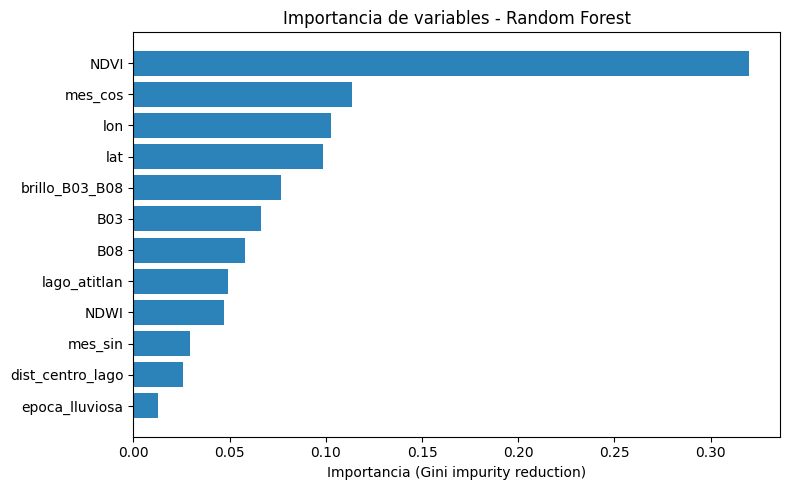

In [10]:
importancias_rf = pd.Series(
    mejor_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importancias_rf.index, importancias_rf.values, color='#2b83ba')
ax.set_xlabel('Importancia (Gini impurity reduction)')
ax.set_title('Importancia de variables - Random Forest')
plt.tight_layout()
plt.show()

## 6. Modelo 3: XGBoost

### 4.1 Entrenamiento inicial

XGBoost es un algoritmo de Gradient Boosting que construye árboles de forma secuencial, donde cada árbol corrige los errores del anterior. Incorpora regularización L1/L2 nativa y maneja internamente el desbalance de clases mediante `scale_pos_weight`.

In [11]:
xgb_inicial = xgb.XGBClassifier(
    n_estimators=50,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    n_jobs=1
)

xgb_inicial.fit(X_train_small, y_train_small)
print('XGBoost inicial entrenado (sobre submuestra).')

XGBoost inicial entrenado (sobre submuestra).


### 4.3 Ajuste de hiperparámetros: XGBoost

Hiperparámetros explorados:
- `n_estimators`: número de árboles secuenciales.
- `learning_rate`: tasa de aprendizaje. Valores menores requieren más árboles.
- `max_depth`: profundidad. XGBoost tiende a requerir árboles más superficiales que RF.
- `subsample`: fracción de filas usadas por árbol.
- `colsample_bytree`: fracción de columnas usadas por árbol.
- `reg_alpha`, `reg_lambda`: regularización L1 y L2.

Search realizado sobre submuestra de 50,000 obs, 3-fold CV, 10 iteraciones. Reentrenamiento final sobre dataset completo.

**Mejores hiperparámetros:** `colsample_bytree=1.0`, `learning_rate=0.150`, `max_depth=5`, `n_estimators=156`, `reg_alpha=1.31`, `reg_lambda=0.244`, `subsample=0.8` — AUC-ROC en CV: **0.9873**

In [12]:
param_dist_xgb = {
    'n_estimators': randint(50, 200),
    'learning_rate': loguniform(0.01, 0.3),
    'max_depth': randint(3, 7),
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': loguniform(1e-3, 10),
    'reg_lambda': loguniform(1e-3, 10)
}

search_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='auc',
        n_jobs=1
    ),
    param_distributions=param_dist_xgb,
    n_iter=10,
    scoring='roc_auc',
    cv=cv_estratificado,
    random_state=42,
    n_jobs=1,
    verbose=1
)

search_xgb.fit(X_train_small, y_train_small)

print(f'Mejores hiperparámetros XGBoost: {search_xgb.best_params_}')
print(f'AUC-ROC en validación cruzada: {search_xgb.best_score_:.4f}')

# Reentrenar con los mejores hiperparámetros sobre el dataset completo
mejor_xgb = search_xgb.best_estimator_
mejor_xgb.fit(X_train, y_train)
print('XGBoost reentrenado sobre X_train completo.')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Mejores hiperparámetros XGBoost: {'colsample_bytree': 1.0, 'learning_rate': np.float64(0.1501725572054684), 'max_depth': 5, 'n_estimators': 156, 'reg_alpha': np.float64(1.3145103232150122), 'reg_lambda': np.float64(0.24400607090817547), 'subsample': 0.8}
AUC-ROC en validación cruzada: 0.9873
XGBoost reentrenado sobre X_train completo.


### Importancia de variables (XGBoost)

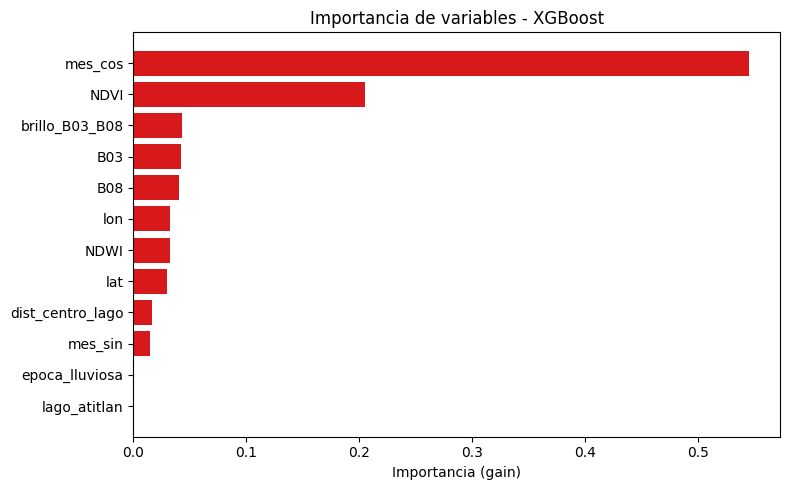

In [13]:
importancias_xgb = pd.Series(
    mejor_xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importancias_xgb.index, importancias_xgb.values, color='#d7191c')
ax.set_xlabel('Importancia (gain)')
ax.set_title('Importancia de variables - XGBoost')
plt.tight_layout()
plt.show()

## 7. Comparación de AUC-ROC en validación cruzada entre los tres modelos

### 4.4 El conjunto de prueba se mantiene constante

Los índices de prueba fueron guardados en el paso 2 y son reutilizados en el notebook 05. Esto garantiza que los tres modelos se comparen exactamente sobre las mismas 4,054,414 observaciones.

**Resumen de AUC-ROC en validación cruzada (submuestra de entrenamiento):**

| Modelo | AUC-ROC (CV) |
|---|---|
| Regresión Logística | 0.9418 |
| Random Forest | **0.9879** |
| XGBoost | 0.9873 |

Random Forest y XGBoost presentan desempeño muy similar en CV, ambos sustancialmente superiores a la Regresión Logística. La evaluación definitiva sobre el conjunto de prueba se realiza en el notebook 05.

In [14]:
resumen_cv = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest', 'XGBoost'],
    'AUC-ROC (CV train)': [
        search_lr.best_score_,
        search_rf.best_score_,
        search_xgb.best_score_
    ],
    'Mejores hiperparámetros': [
        str(search_lr.best_params_),
        str(search_rf.best_params_),
        str(search_xgb.best_params_)
    ]
})

print('Comparación de AUC-ROC en validación cruzada (entrenamiento):')
print(resumen_cv[['Modelo', 'AUC-ROC (CV train)']].to_string(index=False))

Comparación de AUC-ROC en validación cruzada (entrenamiento):
             Modelo  AUC-ROC (CV train)
Regresión Logística            0.941827
      Random Forest            0.987908
            XGBoost            0.987306


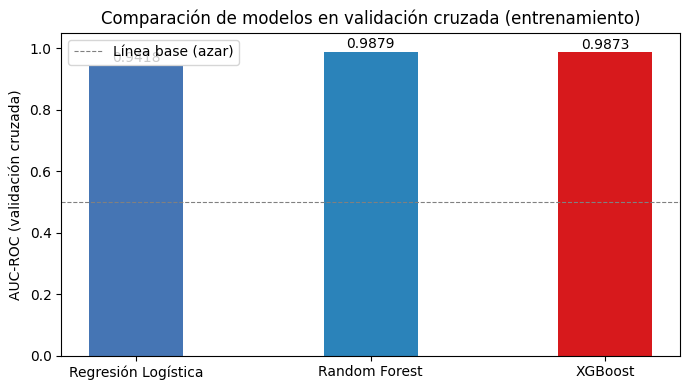

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
modelos = resumen_cv['Modelo']
aucs = resumen_cv['AUC-ROC (CV train)']
bars = ax.bar(modelos, aucs, color=['#4575b4', '#2b83ba', '#d7191c'], width=0.4)
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('AUC-ROC (validación cruzada)')
ax.set_title('Comparación de modelos en validación cruzada (entrenamiento)')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Línea base (azar)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Guardado de modelos

Se guardan los tres modelos optimizados para ser cargados en el notebook 05 (evaluación) y notebooks posteriores.

In [16]:
joblib.dump(mejor_lr, './modelos/modelo_lr.pkl')
joblib.dump(mejor_rf, './modelos/modelo_rf.pkl')
joblib.dump(mejor_xgb, './modelos/modelo_xgb.pkl')

# Guardar también el conjunto de prueba para uso en notebook 05
X_test.to_parquet('./data/X_test.parquet', index=False)
y_test.to_frame().to_parquet('./data/y_test.parquet', index=False)
X_train.to_parquet('./data/X_train.parquet', index=False)
y_train.to_frame().to_parquet('./data/y_train.parquet', index=False)

print('Modelos guardados en ./modelos/')
print('Conjuntos de entrenamiento y prueba guardados en ./data/')

Modelos guardados en ./modelos/
Conjuntos de entrenamiento y prueba guardados en ./data/


## 9. Resumen y justificación de decisiones de modelado

### Criterio para seleccionar el modelo final entre hiperparámetros

El criterio de selección fue **AUC-ROC** en validación cruzada estratificada de 3 folds sobre una submuestra de 50,000 observaciones. Esta elección es apropiada porque:

1. **AUC-ROC es invariante al umbral de decisión** y mide la capacidad discriminatoria general del modelo.
2. **Es razonablemente robusta al desbalance**, a diferencia de la exactitud (accuracy) que sería dominada por la clase mayoritaria.
3. El umbral de decisión óptimo se analiza en el notebook 05 desde la perspectiva ambiental.

### Estrategia para el ajuste de hiperparámetros con dataset grande

Dado que el dataset tiene 9.46M de observaciones de entrenamiento, ejecutar `RandomizedSearchCV` directamente sobre él resultaría en tiempos de cómputo prohibitivos en hardware personal. Se adoptó la siguiente estrategia:

1. **Search sobre submuestra estratificada de 50,000 observaciones** (mantiene la proporción 97.77%/2.23% de clases): 3-fold CV × 10 iteraciones = 30 fits por modelo.
2. **Reentrenamiento final sobre `X_train` completo** con los mejores hiperparámetros encontrados.

Esta estrategia es válida porque la submuestra es suficientemente grande para identificar la región del espacio de hiperparámetros con mejor desempeño, y el reentrenamiento final aprovecha toda la información disponible.

### Manejo del desbalance

Se usó `class_weight='balanced'` (LR, RF) y `scale_pos_weight=43.89` (XGBoost) en lugar de SMOTE porque con millones de píxeles el remuestreo sintético sería computacionalmente prohibitivo y los pesos de clase logran el mismo efecto de equilibrio durante el entrenamiento.

### División 70/30 estratificada

Con solo 2.23% de positivos, la estratificación es crítica: sin ella, la varianza muestral podría producir folds de prueba con proporciones muy distintas de positivos, haciendo las métricas inestables.